# AdapTrans showcase: Transformer on CRCNS AA1

This notebook trains a small **Transformer** on the **CRCNS AA1**
auditory dataset (zebra finch primary auditory and midbrain neurons,
Theunissen group; auto-downloaded via deepSTRF's CRCNS helper) twice
— once **without** any prefiltering, once **with** an **AdapTrans**
prefilter (Rancon et al. 2022) — to demonstrate the prefilter's
contribution. AdapTrans is a learnable cochlear-adaptation
front-end: it implements per-band sliding-window subtractive
adaptation that mimics divisive cortical adaptation observed in
auditory neurons, and is a drop-in `prefiltering=` argument on every
audio model in the deepSTRF zoo.

What you'll see:

1. Auto-load AA1 and restrict to its 20 *conspecific* (natural-sound)
   stimuli — the bidirectional rule (`data_paradigm.md` §8) takes care
   of dropping the 2 cells that only saw the flatrip noise stimuli.
2. Per-band stim standardization — required because AA1 spectrograms
   span ~0–24 in raw amplitude and Transformer attention saturates
   on those values.
3. Train two Transformers with identical hyperparameters except for
   the `prefiltering=` argument.
4. Compare validation curves, test set `cc_norm` distributions, and
   peek at the learned AdapTrans gain envelopes.


## Setup

In [1]:
%matplotlib inline
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio.CRCNS_AA1_Dataset import CRCNS_AA1_Dataset
from deepSTRF.models.audio import Transformer
from deepSTRF.models.prefiltering import make_prefiltering
from deepSTRF.training import Fitter, set_random_seed
from deepSTRF.utils.data import neural_collate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


## 1. Load CRCNS AA1, restrict to conspecific stimuli

`CRCNS_AA1_Dataset` ships 100 cells (Field L + MLd) responding to 20
conspecific natural-sound stimuli plus 10 broadband "flatrip" noise
stimuli; ~34% of (stim, cell) pairs are NaN-padded (cells that only
saw a subset of stims). Restricting to *conspecific* via
`select_stims_by_attr` automatically drops 2 cells that only have
flatrip data — that's the bidirectional rule from
[`data_paradigm.md`](../docs/_source/md/data_paradigm.md) §8.

In [2]:
ds = CRCNS_AA1_Dataset(dt_ms=5)
print(f"All AA1: N={ds.N_neurons} cells, S={len(ds.stims)} stims, F={ds.F} bands")

ds.select_stims_by_attr("type", "conspecific")
S_sel = list(ds.S_sel)
N_sel = len(ds._selected())
print(f"After select_stims_by_attr('type', 'conspecific'): "
      f"{len(S_sel)} stims, {N_sel} visible cells")


All AA1: N=100 cells, S=30 stims, F=32 bands
After select_stims_by_attr('type', 'conspecific'): 20 stims, 98 visible cells


## 2. Per-band stim standardization

AA1 spectrograms are large-amplitude (raw values up to ~24). The
Transformer's attention softmax becomes unstable on those scales —
without standardization, the loss diverges to NaN within a few
gradient steps. We compute per-band mean and std from the train+val
subset (stims 0..16 in the conspecific selection) and apply them to
**all** stims, so the held-out test stims are transformed with the
same statistics — the workflow `standardize_stims` is built for.

In [3]:
trainval_subset = S_sel[:17]   # 14 train + 3 val
stats = ds.standardize_stims(stim_indices=trainval_subset, per_band=True)
print(f"per-band mean range: [{stats['mean'].min():.3f}, {stats['mean'].max():.3f}]")
print(f"per-band std range:  [{stats['std'].min():.3f}, {stats['std'].max():.3f}]")
print(f"After standardization, stim 0 range: "
      f"[{ds.stims[S_sel[0]].min():.2f}, {ds.stims[S_sel[0]].max():.2f}]")


per-band mean range: [0.008, 1.541]
per-band std range:  [0.001, 1.428]
After standardization, stim 0 range: [-2.61, 7.66]


## 3. Train / val / test split

14 train / 3 val / 3 test, all conspecific.

In [4]:
train_idx = S_sel[:14]
val_idx   = S_sel[14:17]
test_idx  = S_sel[17:20]

train_loader = DataLoader(Subset(ds, train_idx), batch_size=1, shuffle=True,
                          collate_fn=neural_collate)
val_loader   = DataLoader(Subset(ds, val_idx),   batch_size=1, shuffle=False,
                          collate_fn=neural_collate)
test_loader  = DataLoader(Subset(ds, test_idx),  batch_size=1, shuffle=False,
                          collate_fn=neural_collate)
print(f"train: {len(train_idx)} stims | val: {len(val_idx)} | test: {len(test_idx)}")


train: 14 stims | val: 3 | test: 3


## 4. Fit-and-evaluate helper

One function builds a `Transformer` with the requested `prefiltering`,
trains it for 80 epochs, and returns history + test metrics + (when
applicable) the trained prefilter for inspection.

In [5]:
def fit_transformer(name, prefilt_factory, max_epochs=80, seed=0):
    set_random_seed(seed)
    pre = prefilt_factory() if prefilt_factory is not None else None
    model = Transformer(
        n_frequency_bands=ds.F,
        embedding_dim=48, n_heads=2, n_layers=1,
        out_neurons=N_sel,
        freq_patch_size=ds.F, time_patch_size=1,
        prefiltering=pre,
    )
    n_params = model.count_trainable_params()
    print(f"  {name:30s}  params: {n_params:,}", flush=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
    fitter = Fitter(
        model, train_loader, val_loader,
        optimizer=optimizer, device=device,
        max_epochs=max_epochs, patience=max_epochs,
        monitor="val_cc_norm", mode="max",
        log_fn=lambda d: None,
    )
    t0 = time.time()
    history = fitter.fit()
    elapsed = time.time() - t0
    test = fitter.evaluate(test_loader)
    return {
        "name": name,
        "model": model,
        "history": history,
        "test_cc": test["cc"].cpu(),
        "test_cc_norm": test["cc_norm"].cpu(),
        "n_params": n_params,
        "elapsed": elapsed,
    }


## 5. Two fits — without vs with AdapTrans

Same Transformer architecture (1-layer, 2-head, embedding 48), same
data, same Fitter defaults. The only difference is the
`prefiltering=` argument.

In [6]:
print("Fitting two Transformers on AA1 conspecific ...")
result_plain     = fit_transformer("Transformer (no prefilter)", None)
result_adaptrans = fit_transformer("Transformer + AdapTrans",
                                   lambda: make_prefiltering("adaptrans", ds.F, dt=ds.dt))


Fitting two Transformers on AA1 conspecific ...
  Transformer (no prefilter)      params: 34,658


  Transformer + AdapTrans         params: 36,290


## 6. Training curves

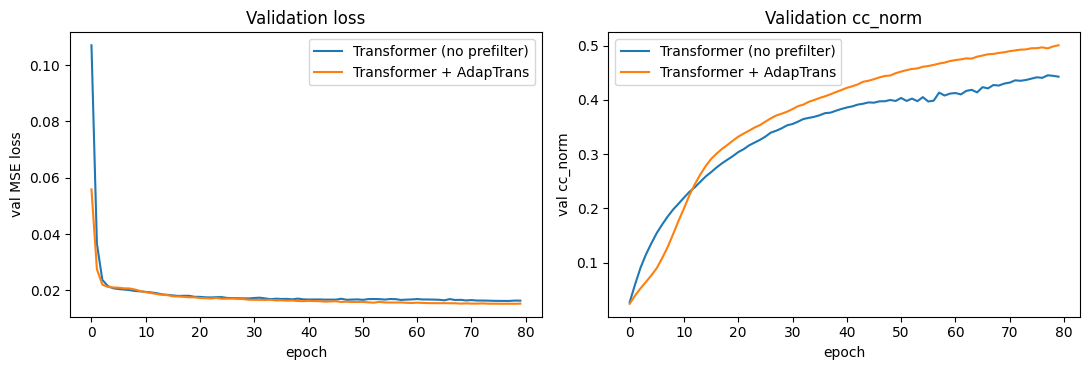

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for r, c in [(result_plain, "tab:blue"), (result_adaptrans, "tab:orange")]:
    ep = [h["epoch"] for h in r["history"]]
    vL = [h["val_loss"] for h in r["history"]]
    vC = [torch.nanmean(h["val_cc_norm"]).item() for h in r["history"]]
    axs[0].plot(ep, vL, label=r["name"], color=c, lw=1.5)
    axs[1].plot(ep, vC, label=r["name"], color=c, lw=1.5)
axs[0].set_xlabel("epoch"); axs[0].set_ylabel("val MSE loss")
axs[0].legend(); axs[0].set_title("Validation loss")
axs[1].set_xlabel("epoch"); axs[1].set_ylabel("val cc_norm")
axs[1].legend(); axs[1].set_title("Validation cc_norm")
plt.tight_layout(); plt.show()


## 7. Test-set summary

In [8]:
print(f"{'configuration':<32s} {'params':>10s}  {'fit (s)':>8s}  {'test cc (mean)':>16s}  {'test cc_norm (mean)':>22s}")
print("-" * 95)
for r in (result_plain, result_adaptrans):
    print(f"{r['name']:<32s} {r['n_params']:>10,}  {r['elapsed']:>8.1f}  "
          f"{torch.nanmean(r['test_cc']):>+16.3f}  {torch.nanmean(r['test_cc_norm']):>+22.3f}")


configuration                        params   fit (s)    test cc (mean)     test cc_norm (mean)
-----------------------------------------------------------------------------------------------
Transformer (no prefilter)           34,658     265.8            +0.390                  +0.496
Transformer + AdapTrans              36,290     254.7            +0.426                  +0.541


## 8. Per-cell test `cc_norm` distributions

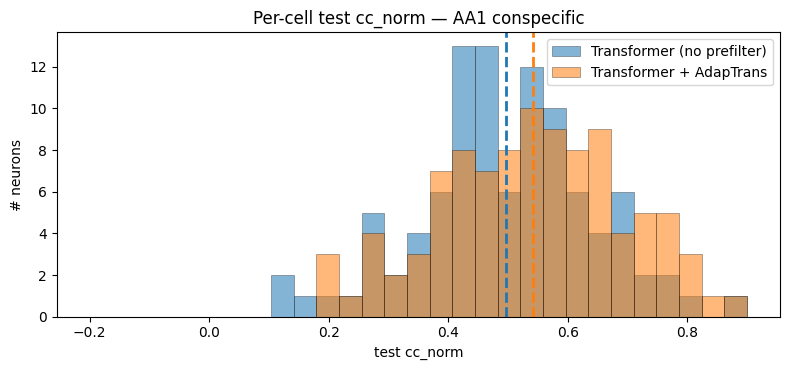

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.8))
bins = np.linspace(-0.2, 0.9, 30)
ax.hist(result_plain["test_cc_norm"].numpy(),     bins=bins, alpha=0.55,
        label=result_plain["name"], color="tab:blue", edgecolor="black", linewidth=0.4)
ax.hist(result_adaptrans["test_cc_norm"].numpy(), bins=bins, alpha=0.55,
        label=result_adaptrans["name"], color="tab:orange", edgecolor="black", linewidth=0.4)
ax.axvline(torch.nanmean(result_plain["test_cc_norm"]).item(), color="tab:blue", lw=2, ls="--")
ax.axvline(torch.nanmean(result_adaptrans["test_cc_norm"]).item(), color="tab:orange", lw=2, ls="--")
ax.set_xlabel("test cc_norm")
ax.set_ylabel("# neurons")
ax.set_title("Per-cell test cc_norm — AA1 conspecific")
ax.legend()
plt.tight_layout(); plt.show()


## 9. Inspect the learned AdapTrans filters

AdapTrans's per-band time-constants are derived from the cochlear
frequency map at init. After training the model adjusts them
independently for the ON and OFF channels. The two panels below show
the learned per-band ``a`` (related to adaptation time-constant — the
larger ``a``, the slower the adaptation) and the ON/OFF kernel for a
representative band.

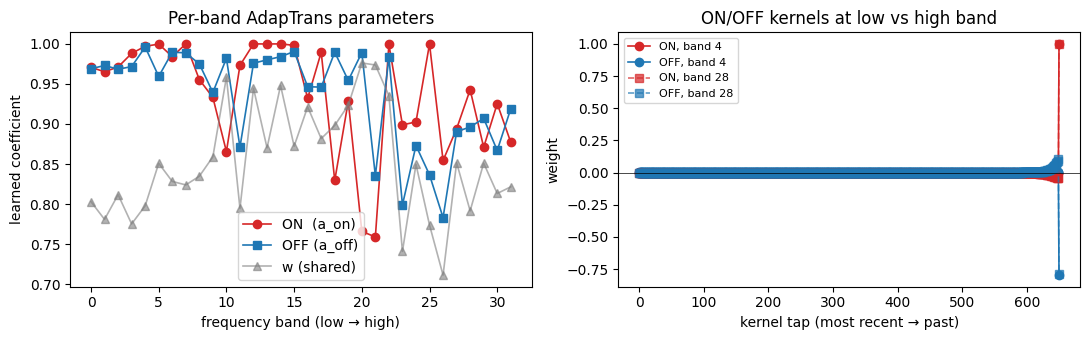

In [10]:
adaptrans = result_adaptrans["model"].prefiltering
a_on, a_off = adaptrans.get_a()
w = adaptrans.get_w()

fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
F_bands = np.arange(adaptrans.F)
axs[0].plot(F_bands, a_on.numpy(),  marker='o', lw=1.2, label='ON  (a_on)',  color='tab:red')
axs[0].plot(F_bands, a_off.numpy(), marker='s', lw=1.2, label='OFF (a_off)', color='tab:blue')
axs[0].plot(F_bands, w.numpy(),     marker='^', lw=1.2, label='w (shared)',  color='tab:gray', alpha=0.6)
axs[0].set_xlabel("frequency band (low → high)")
axs[0].set_ylabel("learned coefficient")
axs[0].set_title("Per-band AdapTrans parameters")
axs[0].legend()

# Show the ON / OFF kernels for a low-frequency and a high-frequency band
with torch.no_grad():
    k_on, k_off = adaptrans.build_kernels()
band_lo, band_hi = 4, adaptrans.F - 4
axs[1].plot(k_on[band_lo, 0].cpu().numpy(),  marker='o', lw=1.2, color='tab:red',
            label=f'ON, band {band_lo}')
axs[1].plot(k_off[band_lo, 0].cpu().numpy(), marker='o', lw=1.2, color='tab:blue',
            label=f'OFF, band {band_lo}')
axs[1].plot(k_on[band_hi, 0].cpu().numpy(),  marker='s', lw=1.2, color='tab:red',
            ls='--', alpha=0.7, label=f'ON, band {band_hi}')
axs[1].plot(k_off[band_hi, 0].cpu().numpy(), marker='s', lw=1.2, color='tab:blue',
            ls='--', alpha=0.7, label=f'OFF, band {band_hi}')
axs[1].axhline(0, color='k', lw=0.5)
axs[1].set_xlabel("kernel tap (most recent → past)")
axs[1].set_ylabel("weight")
axs[1].set_title("ON/OFF kernels at low vs high band")
axs[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## What's next

- **Compare AdapTrans against ICAdaptation** (Willmore et al. 2016
  baseline) — same model, three prefiltering choices: `None`,
  `make_prefiltering('icadaptation', ...)` (paper-faithful, fixed
  time-constants), and `make_prefiltering('adaptrans', ...)`
  (learnable). The two cochlear-adaptation prefilters typically
  match each other and beat `None`; the difference between them is
  small but consistent.
- **Cross-dataset AdapTrans** — same prefilter, fit on NS1, AA1, and
  NAT4 jointly via `concat_neural_datasets`. AdapTrans's per-band
  time-constants generalise across datasets if the spectrogram
  resolution (`F`, `dt`) is shared.
